In [1]:
import os
import re
import torch
import torch.nn as nn

from tqdm import tqdm
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


# =====================
# 1. Preprocessing
# =====================
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text.split()


def build_vocab(texts, max_vocab_size=10000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))

    vocab = {"<PAD>": 0, "<UNK>": 1}
    if max_vocab_size is None:
        max_vocab_size = len(counter)
    for word, freq in counter.most_common(max_vocab_size):
        if freq >= 2:  # remove rare words
            vocab[word] = len(vocab)
    return vocab


def encode(text, vocab, max_len=200):
    '''
    Encode text into sequences
    :param text: 
    :param vocab: 
    :param max_len: 
    :return: 
    '''
    tokens = tokenize(text)  # split text into words
    seq = [vocab.get(word, vocab["<UNK>"]) for word in tokens]
    
    # padding / truncation
    if len(seq) < max_len:
        seq += [vocab["<PAD>"]] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
        
    return seq


# =====================
# 2. Dataset Class
# =====================
class SpamDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=200):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = torch.tensor(encode(self.texts[idx], self.vocab, self.max_len),
                         dtype=torch.long)
        y = torch.tensor(self.labels[idx]).float()
        return x, y


# =====================
# 3. RNN Model
# =====================
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)                  # (B, L, E)
        output, hidden = self.rnn(x)           # hidden: (1, B, H)
        h_T = hidden.squeeze(0)                # (B, H)
        out = self.fc(h_T)                     # (B, 1)
        return self.sigmoid(out).squeeze(1)    # as 1 output (see fc)


# =====================
# 5. Training
# =====================
def train_model(model, train_loader, val_loader, 
                device, criterion, optimizer, 
                epochs=5, patience=5, output_path='checkpoints/ling-spam'):

    best_val_loss = float("inf")
    patience_counter = 0
    best_model_path = f'{output_path}_best_model.pt'
    last_model_path = f'{output_path}_last_model.pt'
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        loop = tqdm(train_loader, desc=f"Training epoch [{epoch+1}/{epochs}]", leave=False)

        for x, y in loop:
            x, y = x.to(device), y.to(device)

            preds = model(x)
            loss = criterion(preds, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # update progress bar
            loop.set_postfix(loss=loss.item())

        avg_train_loss = total_loss / len(train_loader)

        # --- validation ---
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        print(f"Epoch {epoch+1}: "
              f"Train Loss={avg_train_loss:.4f}, "
              f"Val Loss={val_loss:.4f}, "
              f"Val Acc={val_acc:.4f}")
        
        # Save last model
        torch.save(model.state_dict(), last_model_path)
        
        # --- early stopping ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0

            # Save best model
            print(f'\t Best model saved at: {best_model_path}')
            torch.save(model.state_dict(), best_model_path)
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("⛔ Early stopping triggered!")
            break
        

def evaluate(model, loader, criterion):
    model.eval()
    correct, total = 0, 0
    total_loss = 0

    device = next(model.parameters()).device

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            preds = model(x)
            loss = criterion(preds, y)

            total_loss += loss.item()

            preds_label = (preds > 0.5).float()

            correct += (preds_label == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / len(loader)
    acc = correct / total

    return avg_loss, acc


# =====================
# 6. Inference
# =====================
def predict(text, model, vocab, max_len=200):
    model.eval()
    device = next(model.parameters()).device

    x = torch.tensor([encode(text, vocab, max_len)]).to(device)

    with torch.no_grad():
        prob = model(x).item()

    return "spam" if prob > 0.5 else "ham", prob



ModuleNotFoundError: No module named 'torch'

In [1]:
import pandas as pd
# Load the dataset
#data_dir = '../../../../HK1/02VC-Machine-learning-master/04-code/data/ling-spam'
data_dir = '/home/datvt/Documents/projects/mta/ky2t5_deeplearning/python-data-demo/notebooks/mta/ky2t5_deeplearning/data'
data_path = f'{data_dir}/messages.csv'
df = pd.read_csv(data_path)
df

,subject,message,label
0,job posting - apple-iss research center,content - length : 3386 apple-iss research cen...,0
1,NaN,"lang classification grimes , joseph e . and ba...",0
2,query : letter frequencies for text identifica...,i am posting this inquiry for sergei atamas ( ...,0
3,risk,a colleague and i are researching the differin...,0
4,request book information,earlier this morning i was on the phone with a...,0
...,...,...,...
2888,love your profile - ysuolvpv,hello thanks for stopping by ! ! we have taken...,1
2889,you have been asked to join kiddin,"the list owner of : "" kiddin "" has invited you...",1
2890,anglicization of composers ' names,"judging from the return post , i must have sou...",0
2891,"re : 6 . 797 , comparative method : n - ary co...",gotcha ! there are two separate fallacies in t...,0


No. words in the vocabulary: 34187
Some examples:  ['<PAD>', '<UNK>', 'the', 'of', 'and']


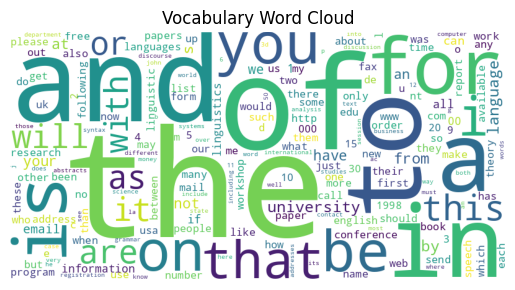

In [3]:
# Get the texts and their labels
texts, labels = df['message'].to_list(), df['label'].to_list()

# Build the vocabulary:
vocab = build_vocab(texts, max_vocab_size=50000)
print('No. words in the vocabulary:', len(vocab))
print('Some examples: ', list(vocab.keys())[:5])

# Visualize the vocab
import matplotlib.pyplot as plt
from wordcloud import WordCloud
# Create word cloud
counter = Counter()
for text in texts:
    counter.update(tokenize(text))
wordcloud = WordCloud(width=800, height=400,
                      background_color='white').generate_from_frequencies(counter)

# Plot
plt.figure()
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Vocabulary Word Cloud")
plt.show()

In [4]:
# Split the dataset into train and test
# Step 1: split train (70%) and temp (30%)
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.3, random_state=42
)

# Step 2: split temp into val (15%) and test (15%)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

# Create datasets
train_dataset = SpamDataset(train_texts, train_labels, vocab)
val_dataset   = SpamDataset(val_texts, val_labels, vocab)
test_dataset  = SpamDataset(test_texts, test_labels, vocab)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)

print('No. training samples:', len(train_dataset))
print('No. validation samples:', len(val_loader))
print('No. test samples:', len(test_dataset))
print('Sample size: ', len(train_dataset[0][0]))  # 200 as max_len=200

No. training samples: 2025
No. validation samples: 14
No. test samples: 434
Sample size:  200


In [5]:
def init_weights(model):
    for name, param in model.named_parameters():

        if 'weight_ih' in name:
            nn.init.xavier_uniform_(param.data)

        elif 'weight_hh' in name:
            nn.init.orthogonal_(param.data)

        elif 'bias' in name:
            param.data.fill_(0)

        elif 'weight' in name:
            nn.init.xavier_uniform_(param.data)
            
# Initialize
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RNNClassifier(len(vocab)).to(device)
model.apply(init_weights)       # optional

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train the model
train_model(model, train_loader, val_loader, 
            device, criterion, optimizer, epochs=200, patience=20,
            output_path='checkpoints/ling-spam-rnn_')

Epoch 1: Train Loss=0.4402, Val Loss=0.4941, Val Acc=0.8111
	 Best model saved at: checkpoints/ling-spam-rnn__best_model.pt


Epoch 2: Train Loss=0.3990, Val Loss=0.4692, Val Acc=0.8111
	 Best model saved at: checkpoints/ling-spam-rnn__best_model.pt


Epoch 3: Train Loss=0.2838, Val Loss=0.4893, Val Acc=0.8226


Epoch 4: Train Loss=0.2297, Val Loss=0.5299, Val Acc=0.7995


Epoch 5: Train Loss=0.2022, Val Loss=0.5285, Val Acc=0.7834


...

Epoch 18: Train Loss=0.1725, Val Loss=0.8885, Val Acc=0.6820


Epoch 19: Train Loss=0.1862, Val Loss=0.6457, Val Acc=0.7189


Epoch 20: Train Loss=0.1761, Val Loss=0.6817, Val Acc=0.7235


Epoch 21: Train Loss=0.1742, Val Loss=0.7701, Val Acc=0.6843


Epoch 22: Train Loss=0.1776, Val Loss=0.9181, Val Acc=0.6452
⛔ Early stopping triggered!


In [7]:
# Inference example
text = "Congratulations! You have won a free lottery ticket"
label, prob = predict(text, model, vocab)
print(f"Prediction: {label}, Probability: {prob:.4f}")

Prediction: ham, Probability: 0.3341
